# Homework 1 - Machine Learning
## Part 1: KNN Classifier (Euclidean Distance, K=3)

Name: Burak Kuruçay
Student Number: 210104004049

---

In this part, we implement a K-Nearest Neighbors (KNN) classifier using Euclidean distance with K=3.  
The model is evaluated using 6-fold cross-validation on the Breast Cancer dataset.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from distance import euclidean_distance
from knn_classifier import KNNClassifier

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(set(y)))

Dataset shape: (569, 30)
Number of classes: 2


In [3]:
print("Feature sample:")
print(X[:2])

print("\nLabels sample:")
print(y[:10])

Feature sample:
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]]

Labels sample:
[0 0 0 0 0 0 0 0 0 0]


In [4]:
kf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

In [5]:
accuracies = []
fold_number = 1

for train_idx, test_idx in kf.split(X, y):
    print(f"\n========== Fold {fold_number} ==========")

    # Split
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Model
    model = KNNClassifier(k=3, distance_func=euclidean_distance)

    start_time = time.perf_counter()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    end_time = time.perf_counter()

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    accuracies.append(acc)

    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Runtime:", end_time - start_time)

    # Detailed reporting for one fold
    if fold_number == 1:
        train_pred = model.predict(X_train)
        train_acc = accuracy_score(y_train, train_pred)

        print("\n--- Detailed Report (Fold 1) ---")
        print("Train Accuracy:", train_acc)
        print("Test Accuracy:", acc)

    fold_number += 1


========== Fold 1 ==========
Accuracy: 0.9894736842105263
Confusion Matrix:
 [[35  1]
 [ 0 59]]
Runtime: 0.2419579999987036

--- Detailed Report (Fold 1) ---
Train Accuracy: 0.9767932489451476
Test Accuracy: 0.9894736842105263

========== Fold 2 ==========
Accuracy: 0.9894736842105263
Confusion Matrix:
 [[35  1]
 [ 0 59]]
Runtime: 0.24012516599759692

========== Fold 3 ==========
Accuracy: 0.9473684210526315
Confusion Matrix:
 [[31  4]
 [ 1 59]]
Runtime: 0.24123366700223414

========== Fold 4 ==========
Accuracy: 0.968421052631579
Confusion Matrix:
 [[32  3]
 [ 0 60]]
Runtime: 0.24177620800037403

========== Fold 5 ==========
Accuracy: 0.9789473684210527
Confusion Matrix:
 [[34  1]
 [ 1 59]]
Runtime: 0.24684433299989905

========== Fold 6 ==========
Accuracy: 0.9468085106382979
Confusion Matrix:
 [[30  5]
 [ 0 59]]
Runtime: 0.24170079099712893


In [6]:
print("\n===== FINAL RESULTS =====")
print("Accuracies per fold:", accuracies)
print("Average Accuracy:", np.mean(accuracies))


===== FINAL RESULTS =====
Accuracies per fold: [0.9894736842105263, 0.9894736842105263, 0.9473684210526315, 0.968421052631579, 0.9789473684210527, 0.9468085106382979]
Average Accuracy: 0.9700821201941022


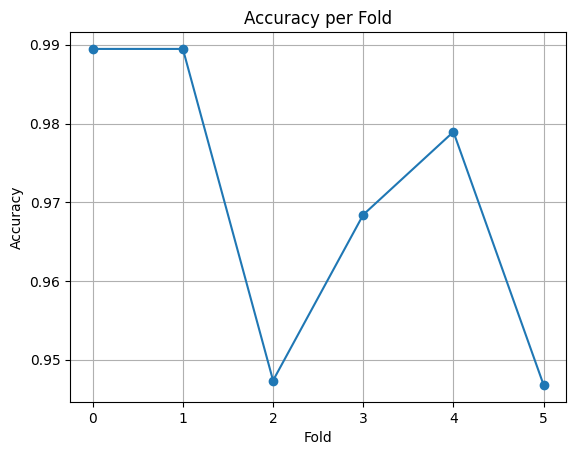

In [7]:
import matplotlib.pyplot as plt

plt.plot(accuracies, marker='o')
plt.title("Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

## Comments

- KNN is a lazy learning algorithm; it does not perform explicit training.
- Most computational cost occurs during prediction since distances are calculated for all training samples.
- Feature scaling is essential because KNN relies on distance calculations.
- Euclidean distance is sensitive to feature magnitude; therefore, StandardScaler was applied.
- The model achieved stable performance across folds, indicating good generalization.
- Confusion matrices show that the classifier performs well, with few misclassifications.
- Increasing K may smooth decision boundaries but could reduce sensitivity to local structure.

## Part 2: KNN Regressor (Manhattan Distance, K=3)

In this part, we implement a K-Nearest Neighbors (KNN) regressor using Manhattan distance with K=3.  
The model is evaluated using 6-fold cross-validation on a regression dataset.

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

from distance import manhattan_distance
from knn_regressor import KNNRegressor

In [9]:
housing = fetch_california_housing()
X_reg = housing.data
y_reg = housing.target

print("Regression dataset shape:", X_reg.shape)
print("First 5 target values:", y_reg[:5])

Regression dataset shape: (20640, 8)
First 5 target values: [4.526 3.585 3.521 3.413 3.422]


In [10]:
kf_reg = KFold(n_splits=6, shuffle=True, random_state=42)

In [11]:
mae_scores = []
mse_scores = []
fold_number = 1

for train_idx, test_idx in kf_reg.split(X_reg):
    print(f"\n========== Regression Fold {fold_number} ==========")

    X_train, X_test = X_reg[train_idx], X_reg[test_idx]
    y_train, y_test = y_reg[train_idx], y_reg[test_idx]

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Model
    model = KNNRegressor(k=3, distance_func=manhattan_distance)

    start_time = time.perf_counter()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    end_time = time.perf_counter()

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    mae_scores.append(mae)
    mse_scores.append(mse)

    print("MAE:", mae)
    print("MSE:", mse)
    print("Runtime:", end_time - start_time)

    # Detailed reporting for one fold
    if fold_number == 1:
        train_pred = model.predict(X_train)
        train_mae = mean_absolute_error(y_train, train_pred)
        train_mse = mean_squared_error(y_train, train_pred)

        print("\n--- Detailed Report (Fold 1) ---")
        print("Train MAE:", train_mae)
        print("Train MSE:", train_mse)
        print("Test MAE:", mae)
        print("Test MSE:", mse)

    fold_number += 1


========== Regression Fold 1 ==========
MAE: 0.43167689825581396
MSE: 0.417926113929312
Runtime: 120.09036624999862

--- Detailed Report (Fold 1) ---
Train MAE: 0.2948438058139535
Train MSE: 0.19789272885465115
Test MAE: 0.43167689825581396
Test MSE: 0.417926113929312

========== Regression Fold 2 ==========
MAE: 0.4228559079457364
MSE: 0.4059494455762758
Runtime: 114.74645170800068

========== Regression Fold 3 ==========
MAE: 0.42132347480620147
MSE: 0.39549895217911496
Runtime: 115.59679658299865

========== Regression Fold 4 ==========
MAE: 0.4040846501937984
MSE: 0.3772387595842667
Runtime: 113.33915691699804

========== Regression Fold 5 ==========
MAE: 0.4273999166666667
MSE: 0.390203661022022
Runtime: 115.14245700000174

========== Regression Fold 6 ==========
MAE: 0.4262587906976744
MSE: 0.4018167604390374
Runtime: 114.5066359170014


In [12]:
print("\n===== FINAL REGRESSION RESULTS =====")
print("MAE per fold:", mae_scores)
print("Average MAE:", np.mean(mae_scores))
print("MSE per fold:", mse_scores)
print("Average MSE:", np.mean(mse_scores))


===== FINAL REGRESSION RESULTS =====
MAE per fold: [0.43167689825581396, 0.4228559079457364, 0.42132347480620147, 0.4040846501937984, 0.4273999166666667, 0.4262587906976744]
Average MAE: 0.42226660642764857
MSE per fold: [0.417926113929312, 0.4059494455762758, 0.39549895217911496, 0.3772387595842667, 0.390203661022022, 0.4018167604390374]
Average MSE: 0.39810561545500484


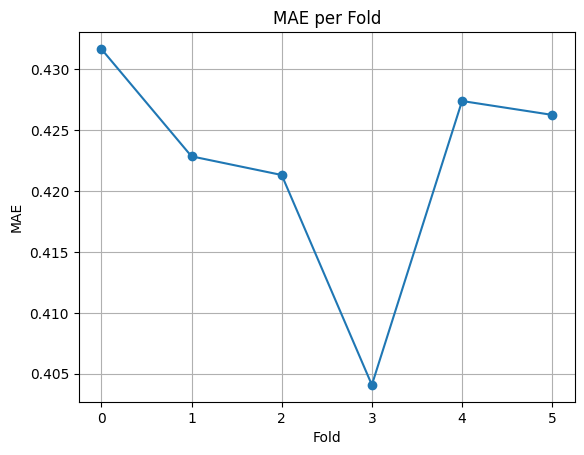

In [13]:
import matplotlib.pyplot as plt

plt.plot(mae_scores, marker='o')
plt.title("MAE per Fold")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.grid()
plt.show()

## Comments

- KNN regression predicts the output by averaging the target values of the nearest neighbors.
- In this part, Manhattan distance was used instead of Euclidean distance.
- Feature scaling is again important because KNN relies on distance calculations.
- The model does not explicitly learn parameters; most of the computational cost is in prediction.
- The fold-based MAE and MSE values show how stable the regressor is across different train/test splits.